In [338]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import cross_val_score, StratifiedKFold

sns.set_style('whitegrid')
sns.set_palette('colorblind')

In [364]:
# Read dataset
df = pd.read_csv('ml-data/dataset_step_count.csv')
df

,participant,cognitive_load,step_interval_cv,step_count,step_rate,step_efficiency,activity_regularity,mean_acceleration_magnitude,mean_velocity_magnitude
0,p4,0,0.388231,40,1.333333,2.575783,103.031337,4.691962,1.283002
1,p4,1,0.545334,37,1.233333,1.833739,67.848334,4.691962,1.283002
2,p5,0,0.430149,36,1.200000,2.324776,83.691952,4.014517,1.075597
3,p5,1,0.548322,31,1.033333,1.823747,56.536147,4.014517,1.075597
4,p8,0,0.327048,45,1.500000,3.057653,137.594401,4.993903,1.023599
5,p8,1,0.476060,38,1.266667,2.100575,79.821855,4.993903,1.023599
6,p9,0,0.452225,39,1.300000,2.211289,86.240264,4.464957,0.988180
7,p9,1,0.430520,38,1.266667,2.322771,88.265300,4.464957,0.988180
8,p10,0,0.346599,46,1.533333,2.885175,132.718061,5.424522,1.079139
9,p10,1,0.598251,38,1.266667,1.671539,63.518470,5.424522,1.079139


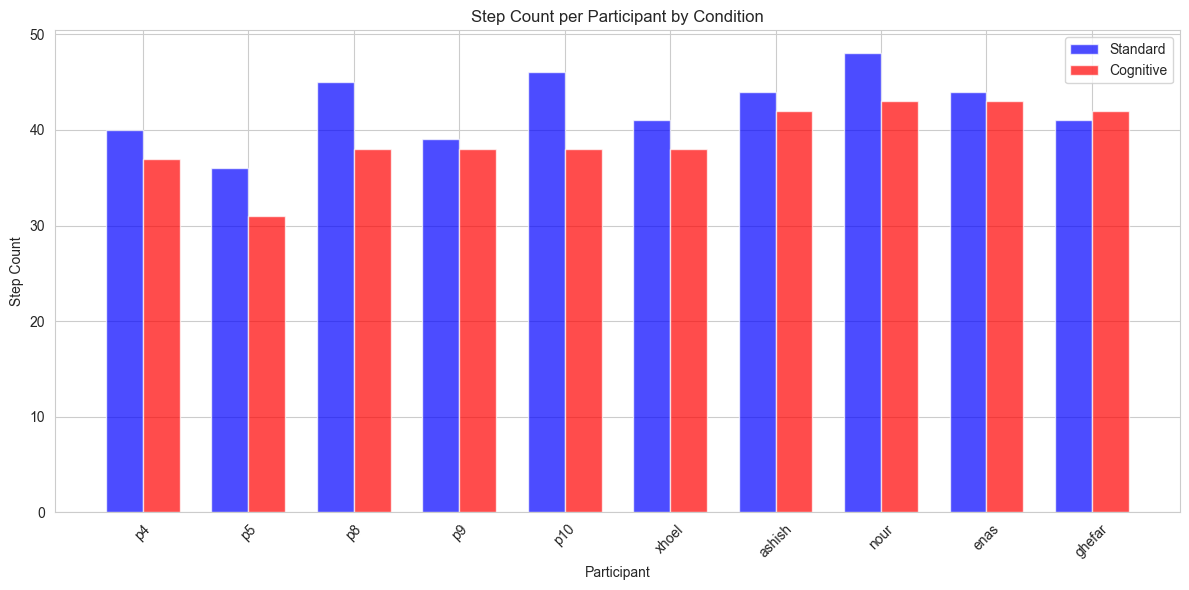

In [340]:
import numpy as np
import matplotlib.pyplot as plt

sns.set_style('whitegrid')
sns.set_palette('colorblind')
# Filter data
df_std = df[df['cognitive_load'] == 0]
df_cog = df[df['cognitive_load'] == 1]

# Align participants by index
participants = df_std['participant'].values
x = np.arange(len(participants))  # integer positions
width = 0.35  # bar width

# Plot
plt.figure(figsize=(12, 6))
plt.bar(x - width/2, df_std['step_count'].values, width=width, label='Standard', color='blue', alpha=0.7)
plt.bar(x + width/2, df_cog['step_count'].values, width=width, label='Cognitive', color='red', alpha=0.7)

# Labels and formatting
plt.xlabel('Participant')
plt.ylabel('Step Count')
plt.title('Step Count per Participant by Condition')
plt.xticks(x, participants, rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

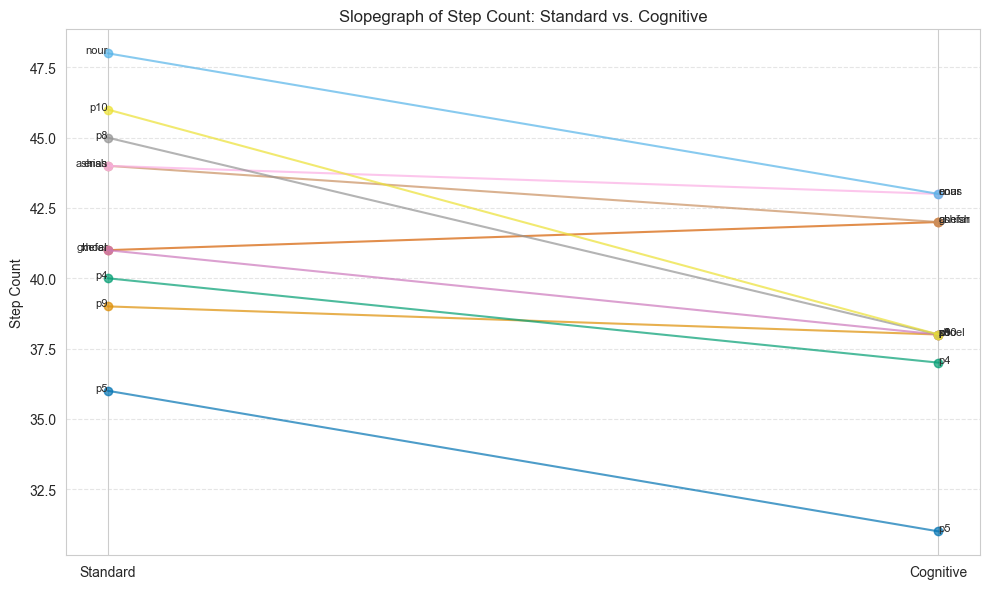

In [341]:
import matplotlib.pyplot as plt

sns.set_style('whitegrid')
sns.set_palette('colorblind')
# Pivot data to have one row per participant and columns for each condition
df_slope = df.pivot(index='participant', columns='cognitive_load', values='step_count')
df_slope.columns = ['Standard', 'Cognitive']  # Rename columns for clarity

# Sort by Standard condition (optional, for aesthetics)
df_slope = df_slope.sort_values(by='Standard')

# Plot
plt.figure(figsize=(10, 6))
for i, row in df_slope.iterrows():
    plt.plot(['Standard', 'Cognitive'], row.values, marker='o', label=i, alpha=0.7)

# Add labels
for i, row in df_slope.iterrows():
    plt.text('Standard', row['Standard'], i, horizontalalignment='right', fontsize=8)
    plt.text('Cognitive', row['Cognitive'], i, horizontalalignment='left', fontsize=8)

plt.title('Slopegraph of Step Count: Standard vs. Cognitive')
plt.ylabel('Step Count')
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [342]:
# Drop non-numeric or irrelevant columns (e.g., participant name)
X = df.drop(columns=['participant', 'cognitive_load'])
y = df['cognitive_load']

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Feature scaling (important for many ML models)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train a classifier (Random Forest here, but you can try others too)
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train_scaled, y_train)

# Predict and evaluate
y_pred = clf.predict(X_test_scaled)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.50      0.67      0.57         3
           1       0.50      0.33      0.40         3

    accuracy                           0.50         6
   macro avg       0.50      0.50      0.49         6
weighted avg       0.50      0.50      0.49         6



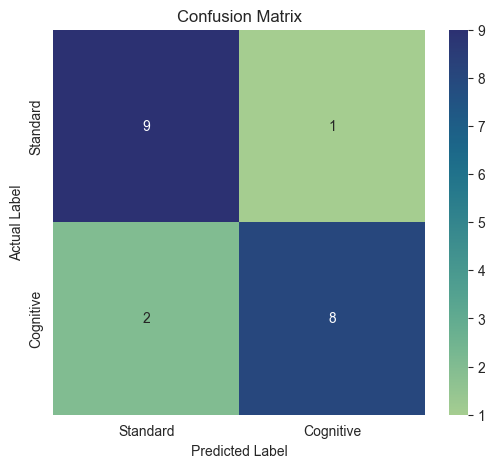

In [343]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

y_pred = clf.predict(X_scaled)
cm = confusion_matrix(y, y_pred)

# Optional: Define class names
class_names = ['Standard', 'Cognitive']
cb_colors = sns.color_palette("colorblind", as_cmap=True)
# Plot heatmap
plt.figure(figsize=(6, 5))
cb_colors = sns.color_palette("colorblind", n_colors=10)  # Adjust n_colors as needed

sns.heatmap(cm, annot=True, fmt='d', 
            xticklabels=class_names, yticklabels=class_names, cmap='crest')

plt.title('Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

In [344]:
# Initialize Logistic Regression model
model = LogisticRegression()

# Stratified 5-Fold Cross-Validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Perform cross-validation
scores = cross_val_score(model, X_scaled, y, cv=cv, scoring='accuracy')

# Display results
print(f"Cross-Validation Accuracy Scores: {scores}")
print(f"Mean Accuracy: {np.mean(scores):.2f}")
print(f"Standard Deviation: {np.std(scores):.2f}")

Cross-Validation Accuracy Scores: [0.5  0.5  1.   0.25 0.75]
Mean Accuracy: 0.60
Standard Deviation: 0.25


In [345]:
# Fit model on train split

model.fit(X_train_scaled, y_train)

# Predict on the test set
y_pred = model.predict(X_test_scaled)

# Evaluate the model
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.67
Confusion Matrix:
 [[2 1]
 [1 2]]
Classification Report:
               precision    recall  f1-score   support

           0       0.67      0.67      0.67         3
           1       0.67      0.67      0.67         3

    accuracy                           0.67         6
   macro avg       0.67      0.67      0.67         6
weighted avg       0.67      0.67      0.67         6



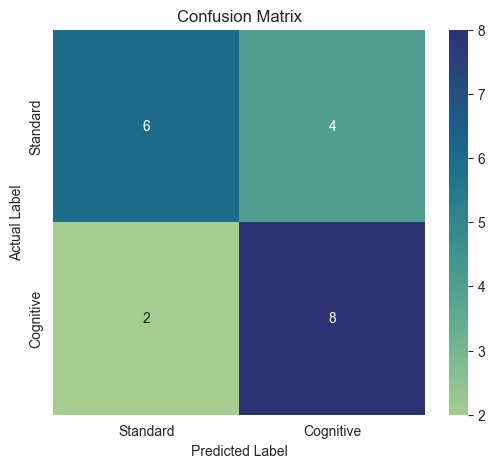

In [346]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

y_pred = model.predict(X_scaled)
cm = confusion_matrix(y, y_pred)

# Optional: Define class names
class_names = ['Standard', 'Cognitive']
cb_colors = sns.color_palette("colorblind", as_cmap=True)
# Plot heatmap
plt.figure(figsize=(6, 5))
cb_colors = sns.color_palette("colorblind", n_colors=10)  # Adjust n_colors as needed

sns.heatmap(cm, annot=True, fmt='d', 
            xticklabels=class_names, yticklabels=class_names, cmap='crest')

plt.title('Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

In [347]:
X.values[:,0]

array([0.3882314 , 0.54533395, 0.43014889, 0.54832177, 0.32704819,
       0.4760601 , 0.45222496, 0.43052026, 0.3465994 , 0.59825119,
       0.47123141, 0.49147563, 0.50003529, 0.4843014 , 0.32753875,
       0.29653703, 0.41178837, 0.39173663, 0.32509993, 0.29576831])

/var/folders/zp/3681gr8x5mg9vt0z3xbtlzx00000gn/T/ipykernel_94738/2243540385.py:33: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  mpatches.Patch(color=color_map[0], label='Standard', edgecolor='k'),
/var/folders/zp/3681gr8x5mg9vt0z3xbtlzx00000gn/T/ipykernel_94738/2243540385.py:34: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  mpatches.Patch(color=color_map[1], label='Cognitive', edgecolor='k')


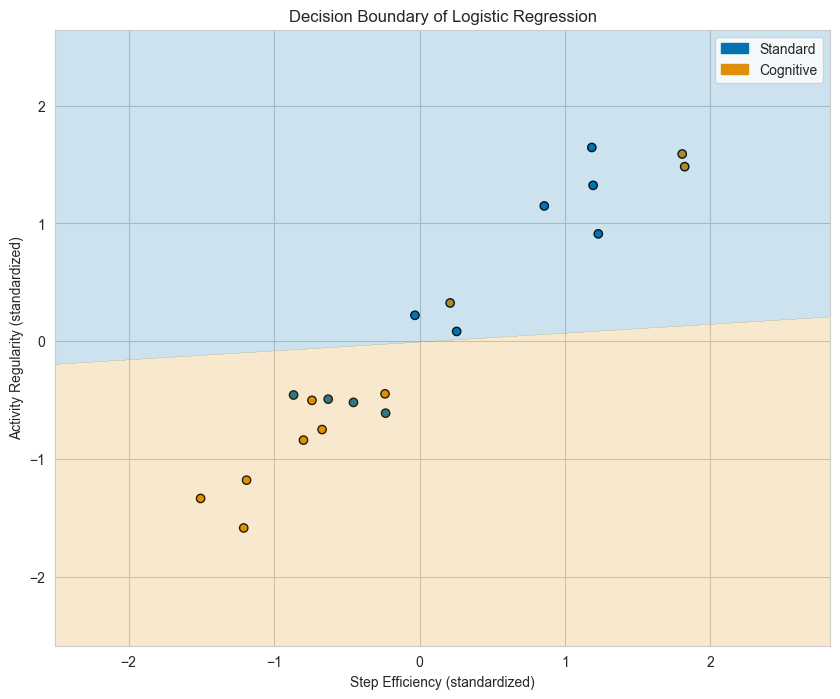

In [348]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Choose two features for 2D visualization
features = ['step_efficiency', 'activity_regularity']
X_vis = df[features].values
y = df['cognitive_load'].values

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_vis)

# Train logistic regression model
model = LogisticRegression()
model.fit(X_scaled, y)

# Set up color palette
plt.figure(figsize=(10, 8))
cb_colors = sns.color_palette("colorblind", n_colors=3)
color_map = {0: cb_colors[0], 1: cb_colors[1]}

# Scatter plot of data points
colors = [color_map[label] for label in y]
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=colors, edgecolor='k')

# Legend
import matplotlib.patches as mpatches
legend_handles = [
    mpatches.Patch(color=color_map[0], label='Standard', edgecolor='k'),
    mpatches.Patch(color=color_map[1], label='Cognitive', edgecolor='k')
]
plt.legend(handles=legend_handles)

# Decision boundary grid
x_min, x_max = X_scaled[:, 0].min() - 1, X_scaled[:, 0].max() + 1
y_min, y_max = X_scaled[:, 1].min() - 1, X_scaled[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))
grid = np.c_[xx.ravel(), yy.ravel()]
probs_grid = model.predict_proba(grid)[:, 1].reshape(xx.shape)

# Contour plot
plt.contourf(xx, yy, probs_grid, levels=[0, 0.5, 1], alpha=0.2, colors=cb_colors)

# Labels and title
plt.xlabel('Step Efficiency (standardized)')
plt.ylabel('Activity Regularity (standardized)')
plt.title('Decision Boundary of Logistic Regression')

plt.show()

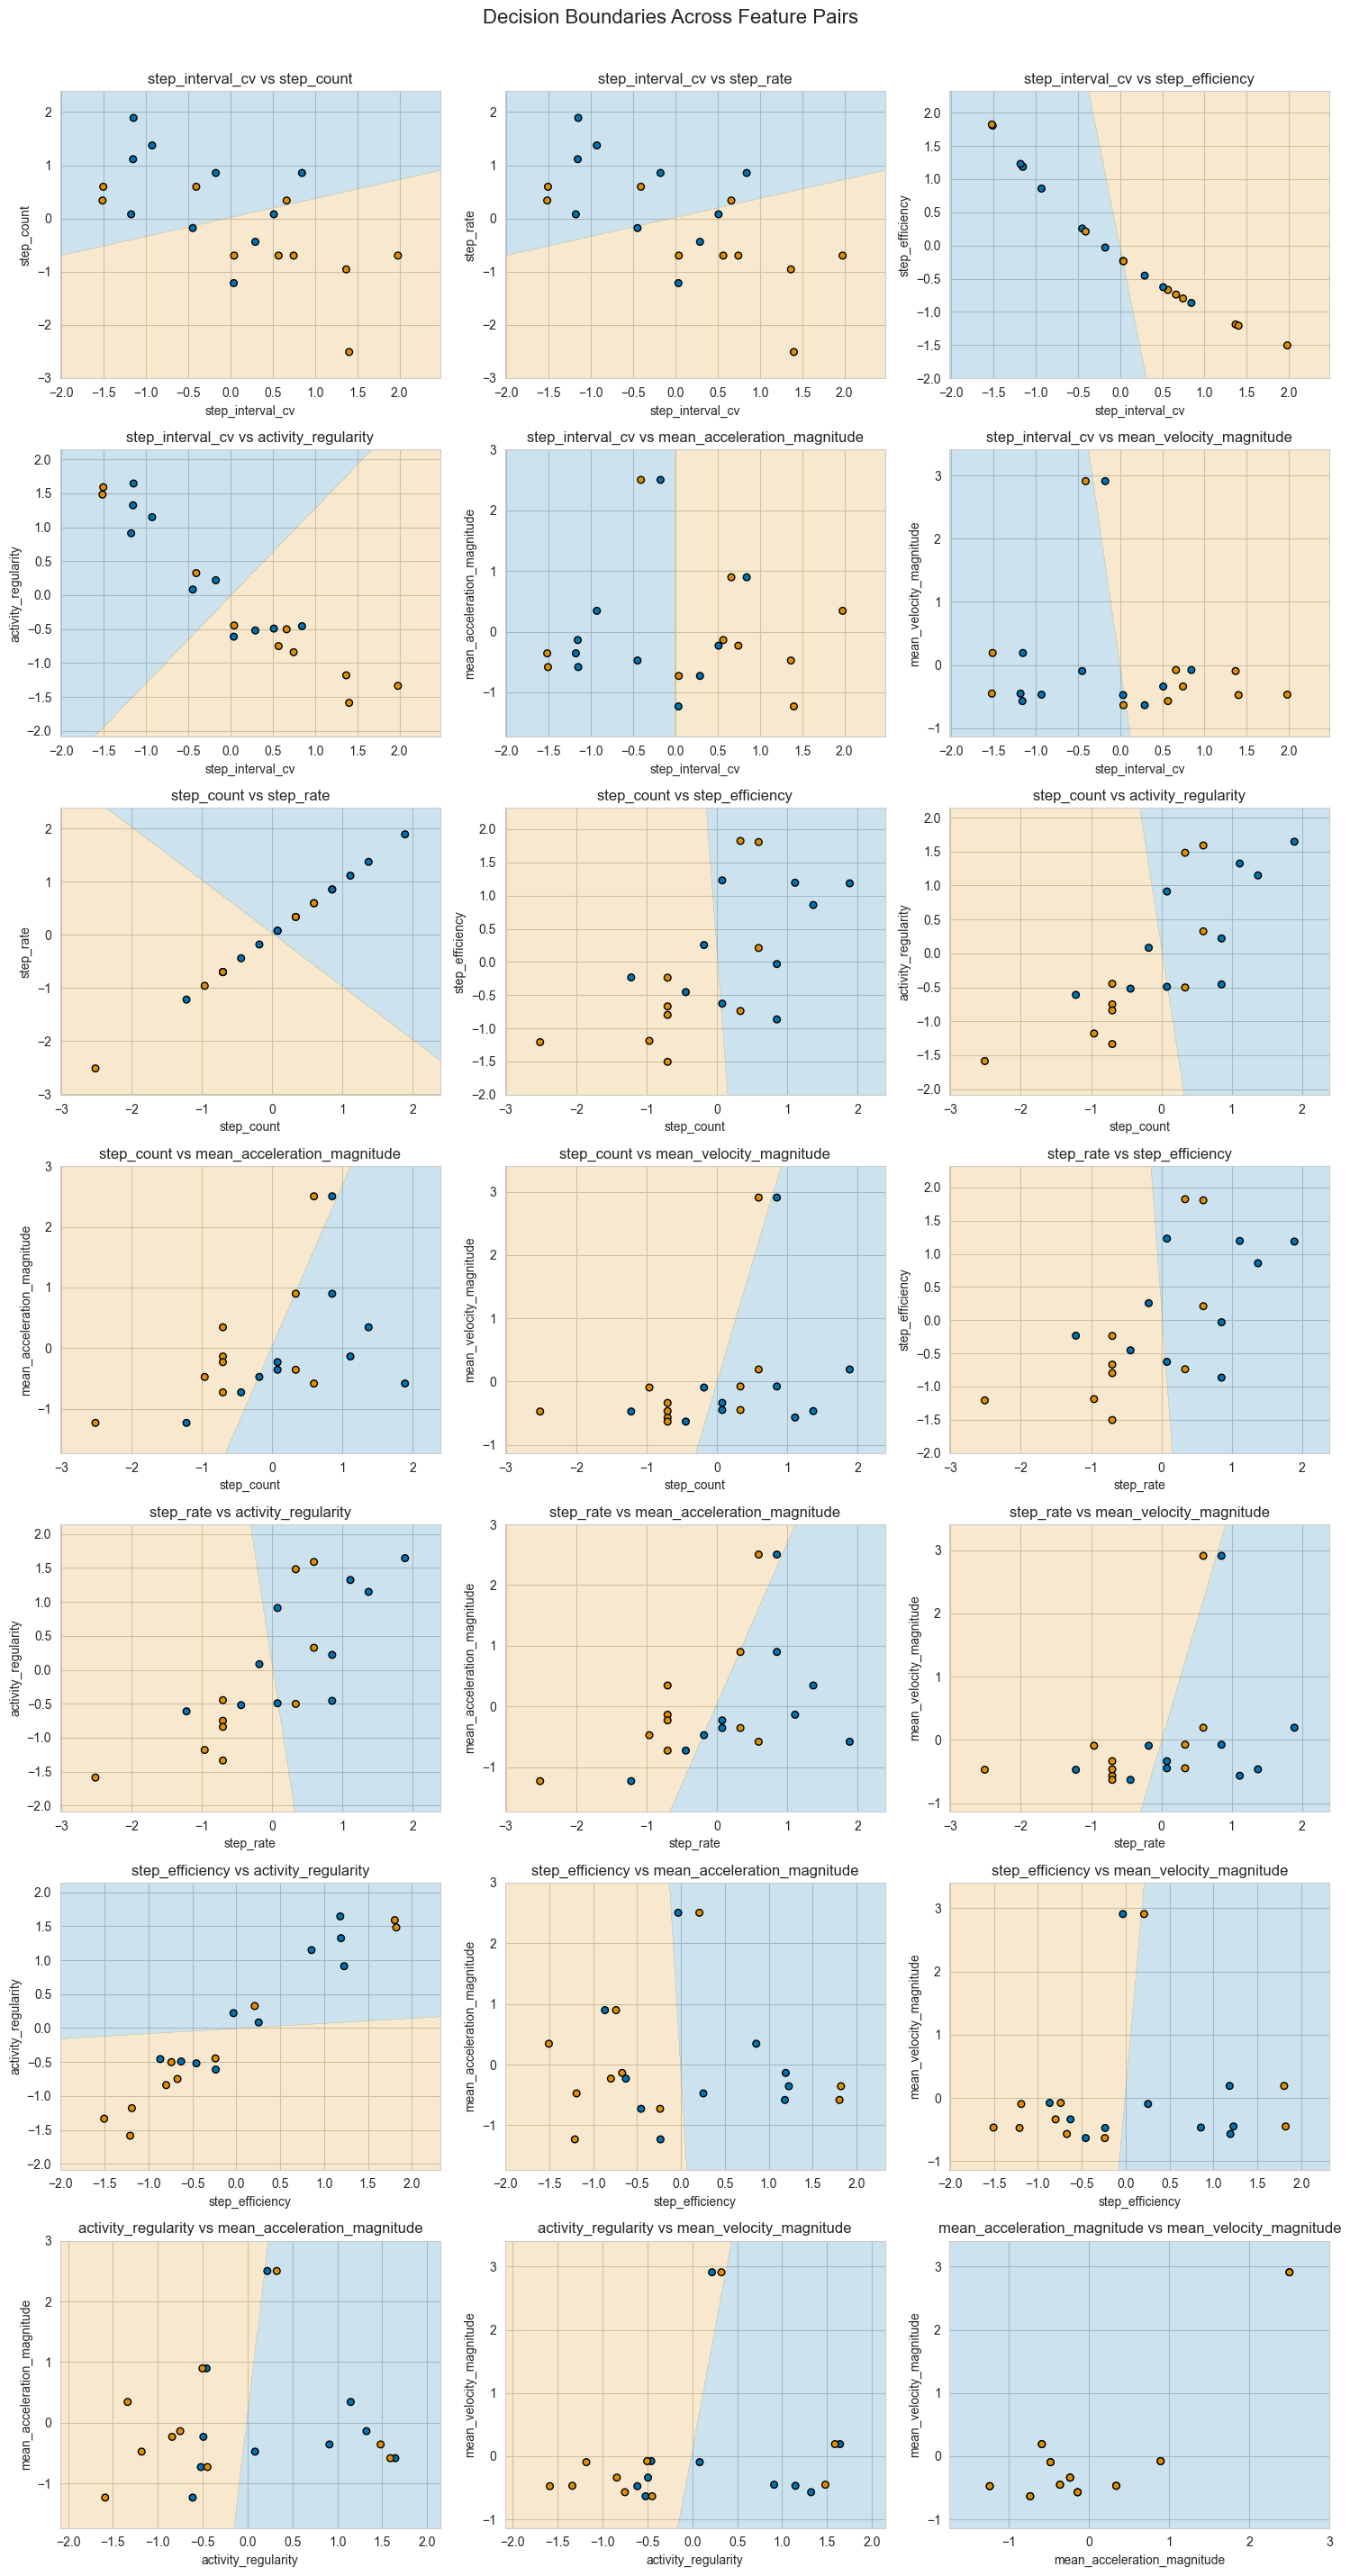

In [349]:
import itertools
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Select features (remove non-numeric and target)
feature_cols = df.drop(columns=['participant', 'cognitive_load']).columns
X = df[feature_cols]
y = df['cognitive_load']

# Scale the entire feature matrix
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=feature_cols)

# Setup for subplots
combinations = list(itertools.combinations(feature_cols, 2))
n_combos = len(combinations)
n_cols = 3
n_rows = int(np.ceil(n_combos / n_cols))

plt.figure(figsize=(n_cols * 5, n_rows * 4))
cb_colors = sns.color_palette("colorblind", n_colors=2)
color_map = {0: cb_colors[0], 1: cb_colors[1]}

for idx, (feat1, feat2) in enumerate(combinations, 1):
    X_pair = X_scaled_df[[feat1, feat2]].values
    clf = LogisticRegression()
    clf.fit(X_pair, y)
    
    # Grid for boundary
    x_min, x_max = X_pair[:, 0].min() - 0.5, X_pair[:, 0].max() + 0.5
    y_min, y_max = X_pair[:, 1].min() - 0.5, X_pair[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))
    grid = np.c_[xx.ravel(), yy.ravel()]
    probs = clf.predict_proba(grid)[:, 1].reshape(xx.shape)
    
    plt.subplot(n_rows, n_cols, idx)
    plt.contourf(xx, yy, probs, levels=[0, 0.5, 1], alpha=0.2, colors=cb_colors)
    plt.scatter(X_pair[:, 0], X_pair[:, 1], c=[color_map[i] for i in y], edgecolor='k', s=30)
    plt.xlabel(feat1)
    plt.ylabel(feat2)
    plt.title(f'{feat1} vs {feat2}')

plt.tight_layout()
plt.suptitle('Decision Boundaries Across Feature Pairs', fontsize=16, y=1.02)
plt.show()

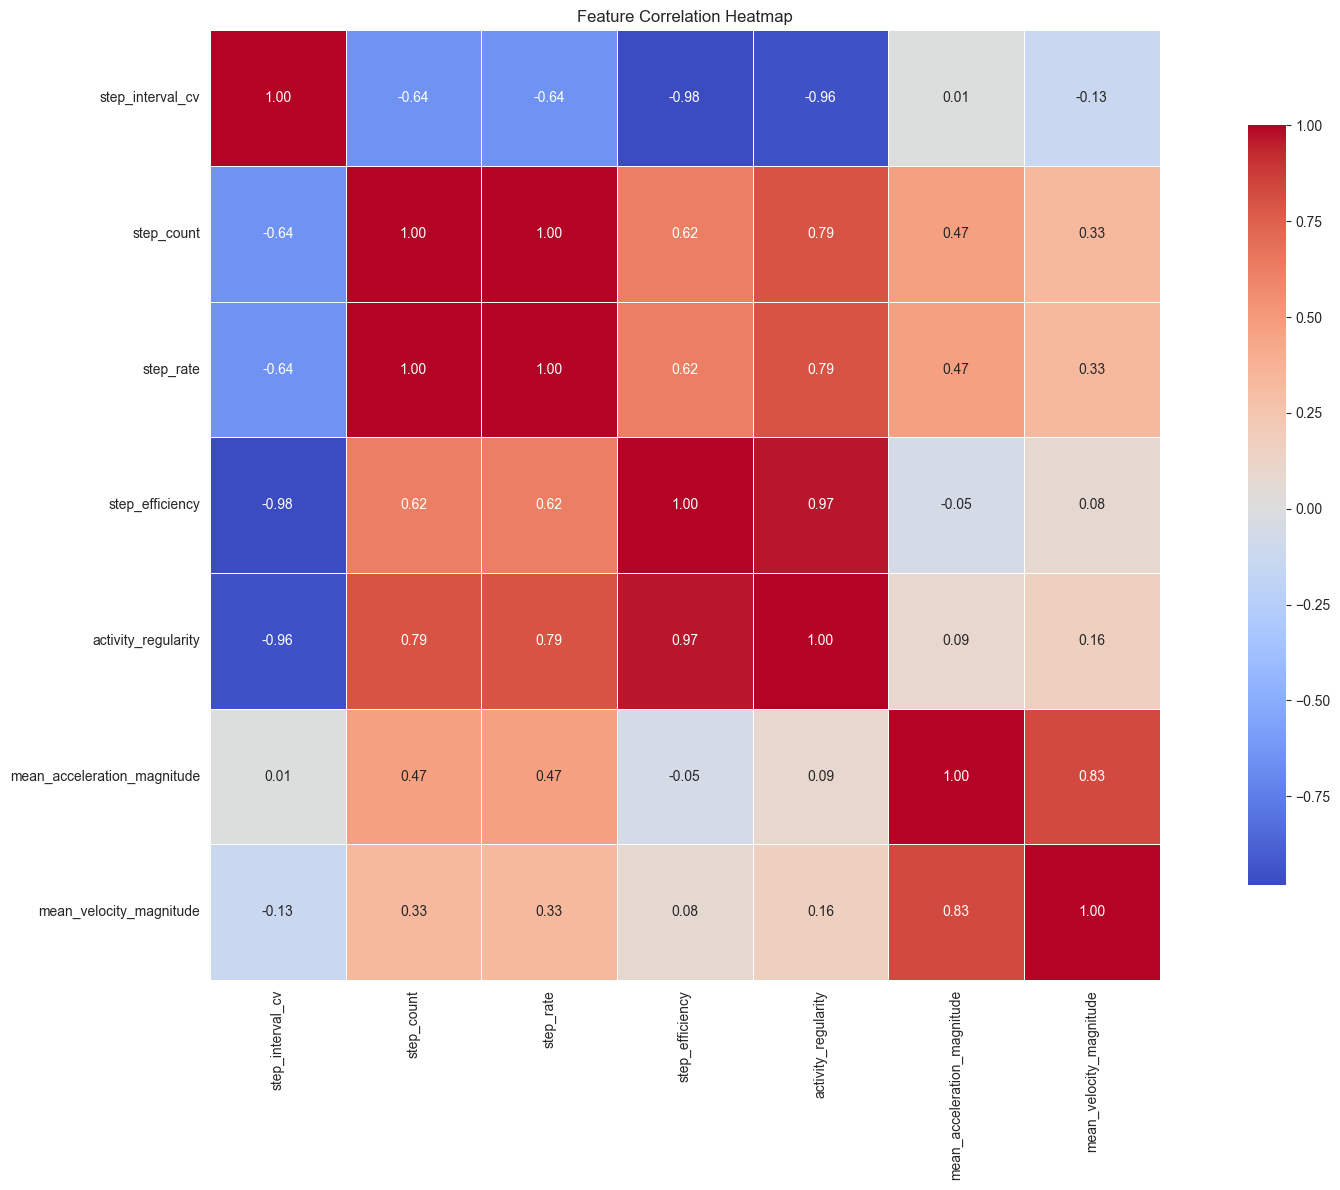

In [350]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select numeric features
feature_cols = df.drop(columns=['participant', 'cognitive_load']).columns
corr_matrix = df[feature_cols].corr()

# Plot heatmap
plt.figure(figsize=(18, 12))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', square=True,
            linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

# Final model training pipeline

## Preprocessing

In [351]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('ml-data/dataset_step_count.csv')

X = df.drop(columns=['participant', 'cognitive_load'])
y = df['cognitive_load']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Models
| Model                | What It Does                                                                 |
|----------------------|------------------------------------------------------------------------------|
| **Logistic Regression** | Draws a straight line (or boundary) to separate classes. Fast and interpretable. |
| **K-Nearest Neighbors (KNN)** | Looks at the 'k' closest data points and picks the most common class. Simple but can be slow. |
| **Support Vector Machine (SVM)** | Finds the best boundary between classes. Works well for both straight and curved boundaries. |
| **Random Forest**     | Combines many decision trees. Great for accuracy and handling complex data. |
| **Gradient Boosting** | Builds trees step-by-step, focusing on mistakes. Often very accurate.       |
| **Naive Bayes**       | Based on probability and assumes features are independent. Fast and works surprisingly well. |

In [352]:
from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
import numpy as np

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

models = {
    'Logistic Regression': LogisticRegression(),
    'KNN': KNeighborsClassifier(),
    'SVM (Linear)': SVC(kernel='linear', probability=True),
    'SVM (RBF)': SVC(kernel='rbf', probability=True),
    'Random Forest': RandomForestClassifier(),
    'Gradient Boosting': GradientBoostingClassifier(),
    'Naive Bayes': GaussianNB()
}

results = []
cv = 5  # 5-fold cross-validation

np.random.seed(42)

for name, model in models.items():
    # Accuracy and F1 scores using cross_val_score (returns array of scores)
    acc_scores = cross_val_score(model, X_scaled, y, cv=cv, scoring='accuracy')
    f1_scores = cross_val_score(model, X_scaled, y, cv=cv, scoring='f1')

    y_probs = cross_val_predict(model, X_scaled, y, cv=cv, method='predict_proba')[:, 1]
    roc_auc = roc_auc_score(y, y_probs)

    results.append({
        'Model': name,
        'Accuracy': np.mean(acc_scores),
        'F1 Score': np.mean(f1_scores),
        'ROC AUC': roc_auc
    })

In [353]:
import pandas as pd
results_df = pd.DataFrame(results).sort_values(by='F1 Score', ascending=False)
results_df

,Model,Accuracy,F1 Score,ROC AUC
4,Random Forest,0.80,0.786667,0.845
2,SVM (Linear),0.70,0.760000,0.700
0,Logistic Regression,0.70,0.726667,0.680
5,Gradient Boosting,0.80,0.693333,0.785
6,Naive Bayes,0.65,0.586667,0.660
3,SVM (RBF),0.70,0.493333,0.240
1,KNN,0.65,0.453333,0.610


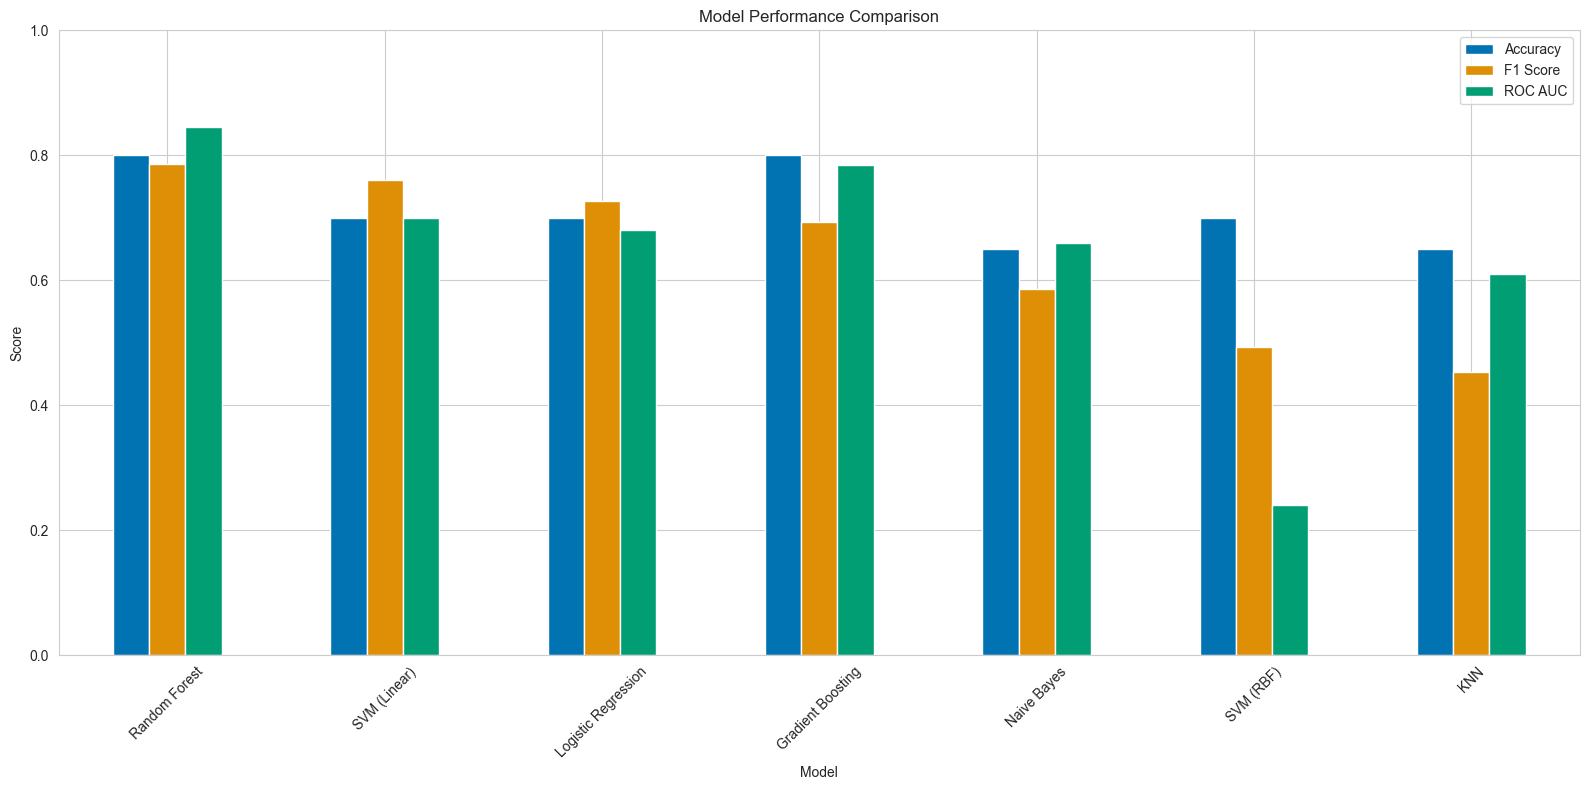

In [354]:
results_df.set_index('Model')[['Accuracy', 'F1 Score', 'ROC AUC']].plot(kind='bar', figsize=(16, 8))
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

Confusion matrix for: Logistic Regression


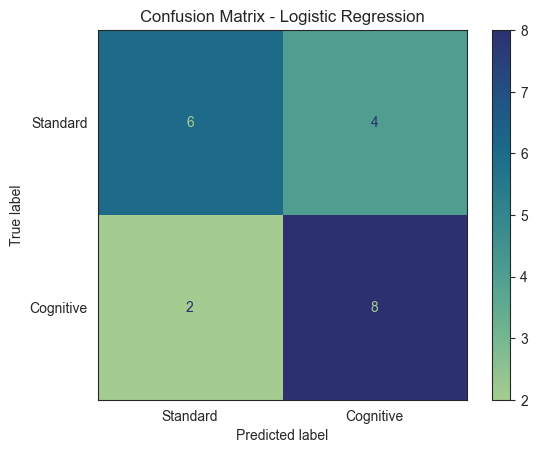

Confusion matrix for: KNN


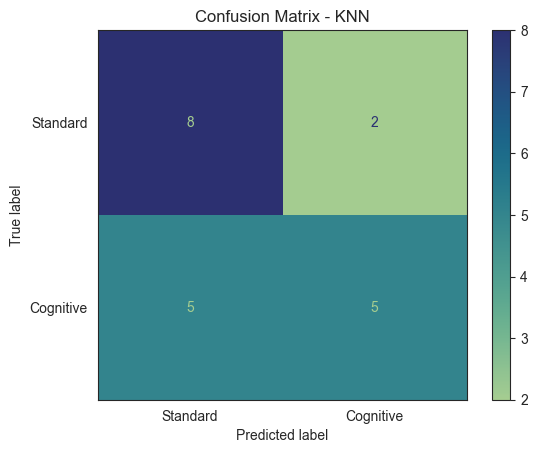

Confusion matrix for: SVM (Linear)


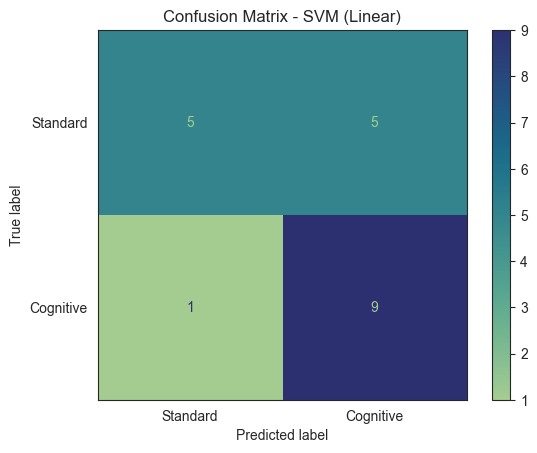

Confusion matrix for: SVM (RBF)


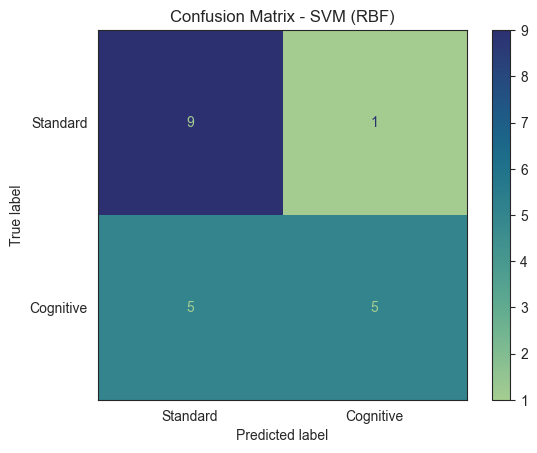

Confusion matrix for: Random Forest


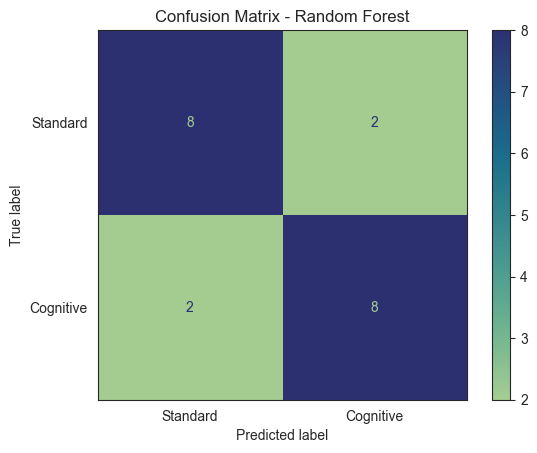

Confusion matrix for: Gradient Boosting


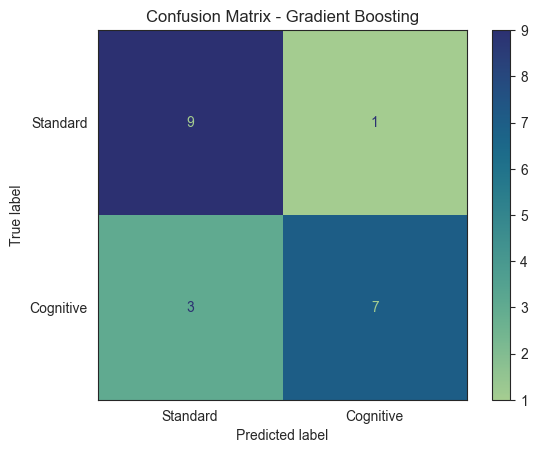

Confusion matrix for: Naive Bayes


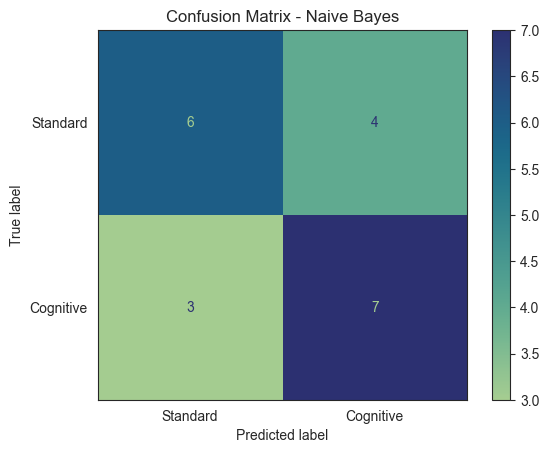

In [355]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import cross_val_predict
sns.set_style('white')

for name, model in models.items():
    print(f"Confusion matrix for: {name}")
    
    # Get cross-validated predictions (labels)
    y_pred_cv = cross_val_predict(model, X_scaled, y, cv=cv)
    
    # Compute confusion matrix
    cm = confusion_matrix(y, y_pred_cv)
    
    # Display
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Standard', 'Cognitive'])
    disp.plot(cmap='crest', values_format='d')
    plt.title(f'Confusion Matrix - {name}')
    plt.show()

# Hyperparam tuned models

In [356]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
import numpy as np
from sklearn.model_selection import cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Models and hyperparameters
model_configs = {
    'Logistic Regression': {
        'enabled': True,
        'description': 'Linear model for binary classification',
        'model': Pipeline([
            # ('scaler', StandardScaler()),
            ('clf', LogisticRegression(max_iter=1000))
        ]),
        'params': {
            'clf__C': [0.01, 0.1, 1, 10],
            'clf__penalty': ['l2'],
            'clf__solver': ['lbfgs']
        }
    },
    'KNN': {
        'enabled': True,
        'description': 'Instance-based learner using nearest neighbors',
        'model': Pipeline([
            ('scaler', StandardScaler()),
            ('clf', KNeighborsClassifier())
        ]),
        'params': {
            'clf__n_neighbors': [3, 5, 7, 9],
            'clf__weights': ['uniform', 'distance']
        }
    },
    'SVM (Linear)': {
        'enabled': True,
        'description': 'Linear Support Vector Classifier',
        'model': Pipeline([
            ('scaler', StandardScaler()),
            ('clf', SVC(kernel='linear', probability=True))
        ]),
        'params': {
            'clf__C': [0.1, 1, 10]
        }
    },
    'SVM (RBF)': {
        'enabled': True,
        'description': 'Non-linear SVM with RBF kernel',
        'model': Pipeline([
            ('scaler', StandardScaler()),
            ('clf', SVC(kernel='rbf', probability=True))
        ]),
        'params': {
            'clf__C': [0.1, 1, 10],
            'clf__gamma': ['scale', 'auto']
        }
    },
    'Random Forest': {
        'enabled': True,
        'description': 'Ensemble of decision trees with bagging',
        'model': RandomForestClassifier(),
        'params': {
            'n_estimators': [50, 100, 200],
            'max_depth': [None, 5, 10],
            'min_samples_split': [2, 5]
        }
    },
    'Gradient Boosting': {
        'enabled': True,
        'description': 'Boosted trees for improved accuracy',
        'model': GradientBoostingClassifier(),
        'params': {
            'n_estimators': [50, 100],
            'learning_rate': [0.05, 0.1, 0.2],
            'max_depth': [3, 5],
            'subsample': [0.8, 1.0]
        }
    },
    'Naive Bayes': {
        'enabled': True,
        'description': 'Simple probabilistic model assuming independence',
        'model': GaussianNB(),
        'params': {}
    }
}

results = []

for name, config in model_configs.items():
    print(f"Tuning {name}")
    grid = GridSearchCV(config['model'], config['params'], cv=5, scoring='f1', n_jobs=-1)
    grid.fit(X_scaled, y)
    
    best_model = grid.best_estimator_
    y_pred = cross_val_predict(best_model, X_scaled, y, cv=5)
    y_prob = cross_val_predict(best_model, X_scaled, y, cv=5, method='predict_proba')[:, 1] if hasattr(best_model, 'predict_proba') else None

    results.append({
        'Model': name,
        'Best Params': grid.best_params_,
        'Accuracy': accuracy_score(y, y_pred),
        'F1 Score': f1_score(y, y_pred),
        'ROC AUC': roc_auc_score(y, y_prob) if y_prob is not None else None
    })
    

Tuning Logistic Regression
Tuning KNN
Tuning SVM (Linear)
Tuning SVM (RBF)
Tuning Random Forest
Tuning Gradient Boosting
Tuning Naive Bayes


In [357]:
import pandas as pd
results_df_ht = pd.DataFrame(results).sort_values(by='F1 Score', ascending=False)
results_df_ht

,Model,Best Params,Accuracy,F1 Score,ROC AUC
5,Gradient Boosting,"{'learning_rate': 0.05, 'max_depth': 5, 'n_est...",0.75,0.761905,0.830
2,SVM (Linear),{'clf__C': 1},0.70,0.750000,0.330
0,Logistic Regression,"{'clf__C': 10, 'clf__penalty': 'l2', 'clf__sol...",0.70,0.727273,0.740
3,SVM (RBF),"{'clf__C': 10, 'clf__gamma': 'scale'}",0.75,0.705882,0.790
4,Random Forest,"{'max_depth': None, 'min_samples_split': 5, 'n...",0.70,0.700000,0.780
1,KNN,"{'clf__n_neighbors': 3, 'clf__weights': 'unifo...",0.65,0.666667,0.725
6,Naive Bayes,{},0.65,0.666667,0.660


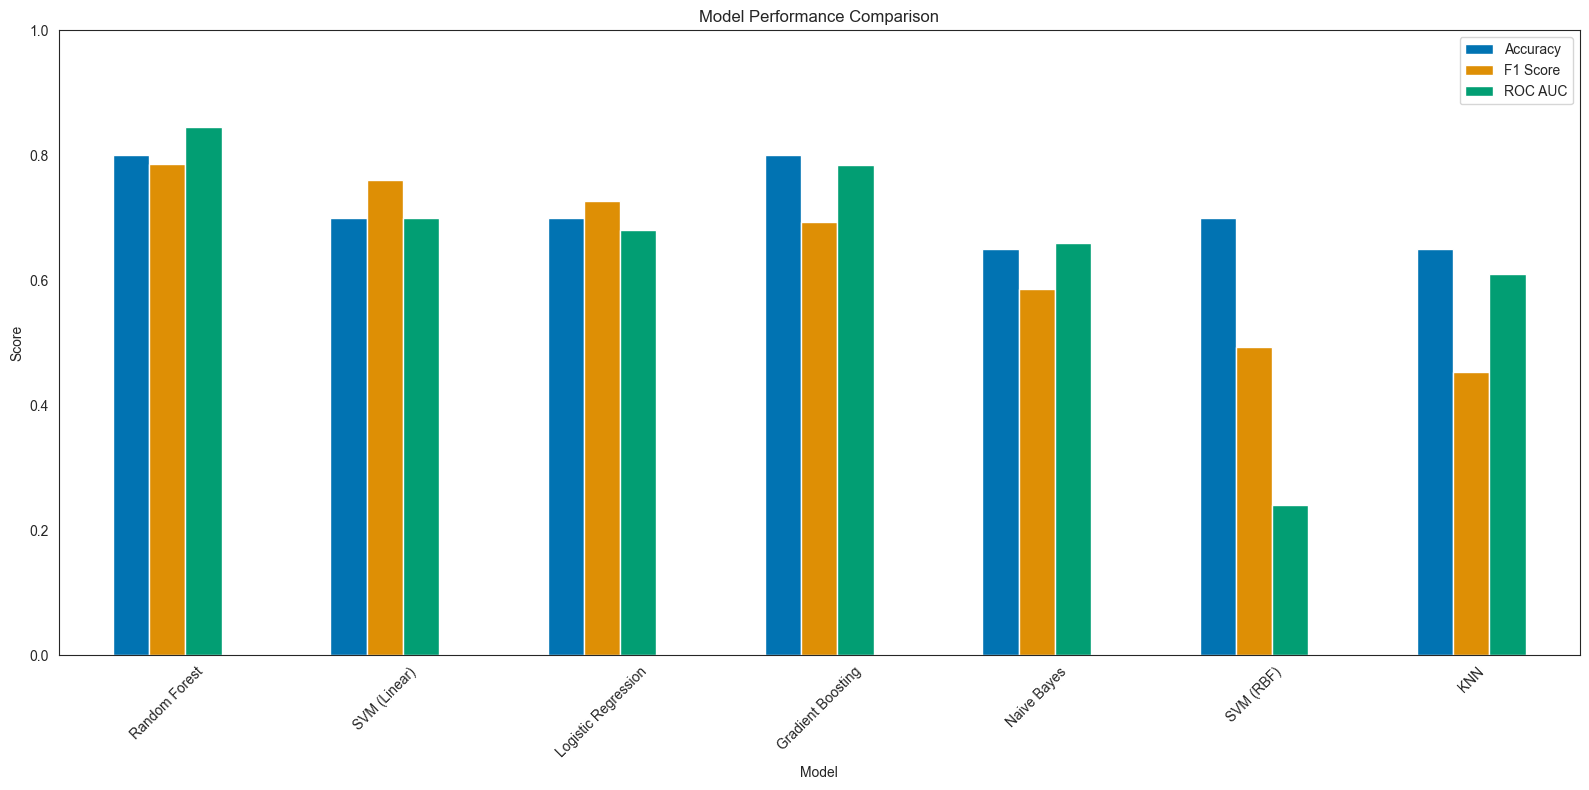

In [358]:
results_df.set_index('Model')[['Accuracy', 'F1 Score', 'ROC AUC']].plot(kind='bar', figsize=(16, 8))
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

Confusion matrix for: Logistic Regression


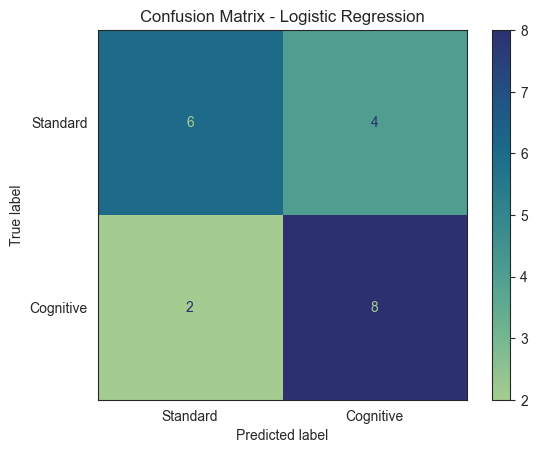

Confusion matrix for: KNN


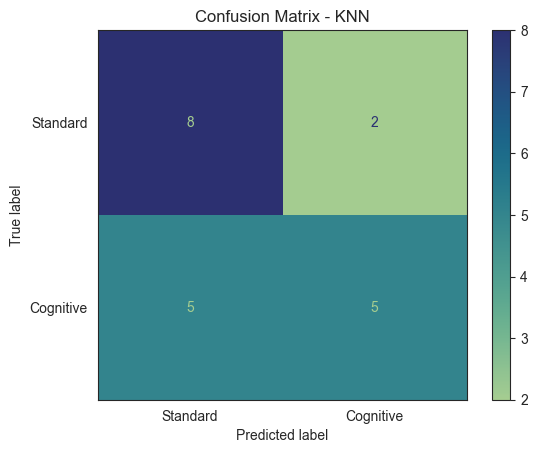

Confusion matrix for: SVM (Linear)


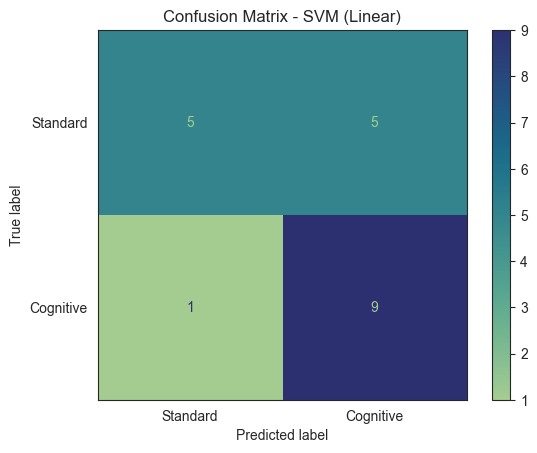

Confusion matrix for: SVM (RBF)


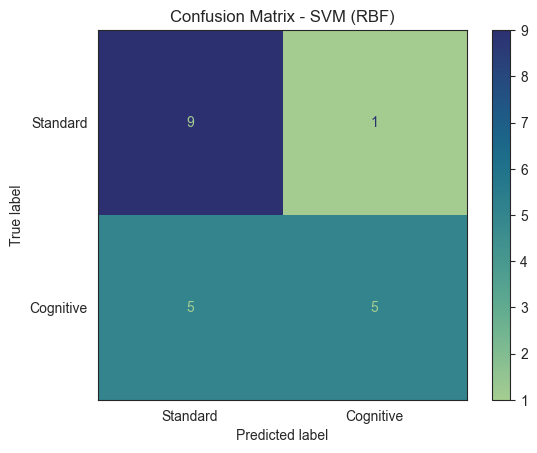

Confusion matrix for: Random Forest


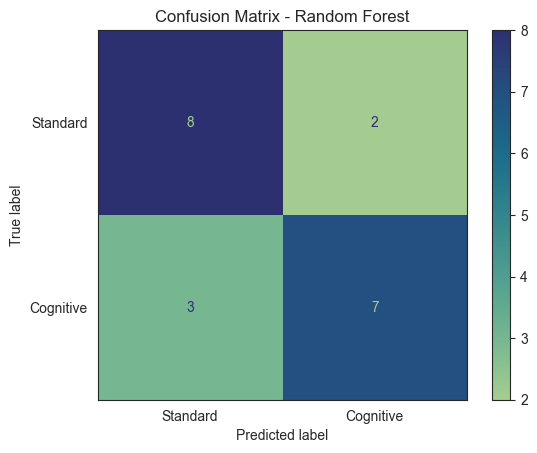

Confusion matrix for: Gradient Boosting


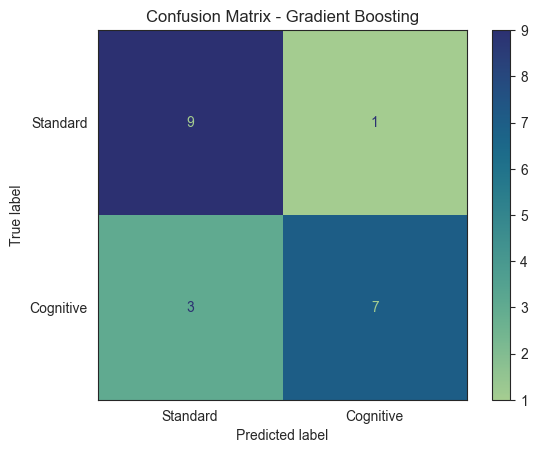

Confusion matrix for: Naive Bayes


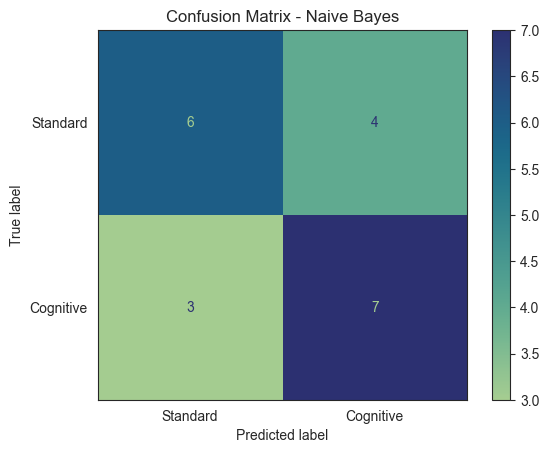

In [359]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import cross_val_predict
sns.set_style('white')

for name, model in models.items():
    print(f"Confusion matrix for: {name}")
    
    # Get cross-validated predictions (labels)
    y_pred_cv = cross_val_predict(model, X_scaled, y, cv=cv)
    
    # Compute confusion matrix
    cm = confusion_matrix(y, y_pred_cv)
    
    # Display
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Standard', 'Cognitive'])
    disp.plot(cmap='crest', values_format='d')
    plt.title(f'Confusion Matrix - {name}')
    plt.show()

# Compare perfornance boost

In [360]:
# Rename columns for clarity
base = results_df.rename(columns={
    'Accuracy': 'Accuracy_Base',
    'F1 Score': 'F1_Base',
    'ROC AUC': 'ROC_AUC_Base'
})

tuned = results_df_ht.rename(columns={
    'Accuracy': 'Accuracy_Tuned',
    'F1 Score': 'F1_Tuned',
    'ROC AUC': 'ROC_AUC_Tuned'
})

# Merge on model name
comparison_df = pd.merge(base, tuned, on='Model')

In [361]:
comparison_df

,Model,Accuracy_Base,F1_Base,ROC_AUC_Base,Best Params,Accuracy_Tuned,F1_Tuned,ROC_AUC_Tuned
0,Random Forest,0.80,0.786667,0.845,"{'max_depth': None, 'min_samples_split': 5, 'n...",0.70,0.700000,0.780
1,SVM (Linear),0.70,0.760000,0.700,{'clf__C': 1},0.70,0.750000,0.330
2,Logistic Regression,0.70,0.726667,0.680,"{'clf__C': 10, 'clf__penalty': 'l2', 'clf__sol...",0.70,0.727273,0.740
3,Gradient Boosting,0.80,0.693333,0.785,"{'learning_rate': 0.05, 'max_depth': 5, 'n_est...",0.75,0.761905,0.830
4,Naive Bayes,0.65,0.586667,0.660,{},0.65,0.666667,0.660
5,SVM (RBF),0.70,0.493333,0.240,"{'clf__C': 10, 'clf__gamma': 'scale'}",0.75,0.705882,0.790
6,KNN,0.65,0.453333,0.610,"{'clf__n_neighbors': 3, 'clf__weights': 'unifo...",0.65,0.666667,0.725


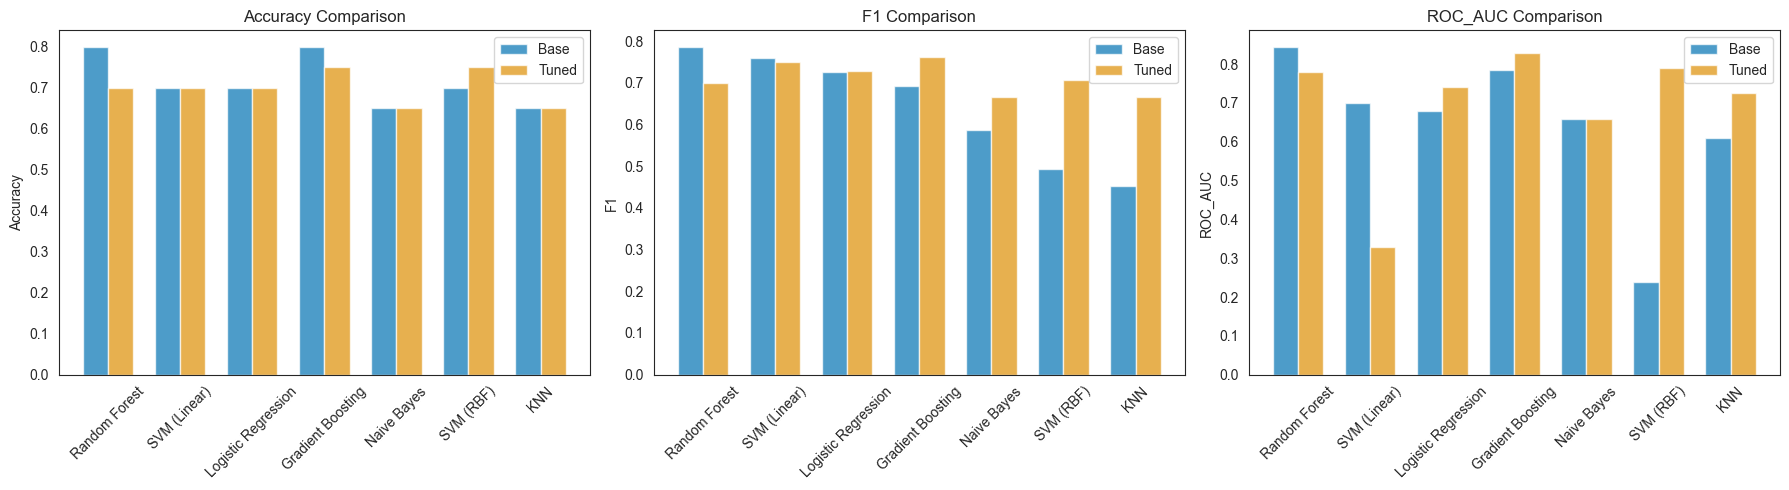

In [362]:
import matplotlib.pyplot as plt
import numpy as np

metrics = ['Accuracy', 'F1', 'ROC_AUC']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
bar_width = 0.35
x = np.arange(len(comparison_df['Model']))

for i, metric in enumerate(metrics):
    axes[i].bar(x - bar_width/2, comparison_df[f'{metric}_Base'], width=bar_width, label='Base', alpha=0.7)
    axes[i].bar(x + bar_width/2, comparison_df[f'{metric}_Tuned'], width=bar_width, label='Tuned', alpha=0.7)
    
    axes[i].set_title(f'{metric} Comparison')
    axes[i].set_ylabel(metric)
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(comparison_df['Model'], rotation=45)

    axes[i].legend()
plt.tight_layout()
plt.show()

In [363]:
for metric in metrics:
    diff = comparison_df[f'{metric}_Tuned'] - comparison_df[f'{metric}_Base']
    improved_models = comparison_df['Model'][diff > 0].tolist()
    print(f"{metric}: {len(improved_models)} model(s) improved → {improved_models}")

Accuracy: 1 model(s) improved → ['SVM (RBF)']
F1: 5 model(s) improved → ['Logistic Regression', 'Gradient Boosting', 'Naive Bayes', 'SVM (RBF)', 'KNN']
ROC_AUC: 4 model(s) improved → ['Logistic Regression', 'Gradient Boosting', 'SVM (RBF)', 'KNN']
